In [ ]:
import pandas as pd
import os
from config import DATA_DIR


print("Loading data to RAM...")
csv_file_path = os.path.join(DATA_DIR, 'processed_data.csv')

df = pd.read_csv(csv_file_path)
print("Data loaded successfully!")
print(f"Top 5 ECUs:")
print(df['CAN_ID'].value_counts().head(5))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

print(f"Module 688 isolation...")
TARGET_ID = 688
df_688 = df[df['CAN_ID'] == TARGET_ID].copy()
print(f"Frames left: {len(df_688)}")

df_688 = df_688[df_688['delta_t'] > 0.0]

X_raw = df_688.drop(columns=['Timestamp', 'CAN_ID'])
X_raw = X_raw.fillna(0)

print("Data before scaling (first row):")
print(X_raw.iloc[0].values)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Data after scaling (first row):")
print(X_scaled[0])

print("Final shape: ", X_scaled.shape)

# Porównanie wpływu funkcji aktywacyjnej na konwergencję autoenkodera
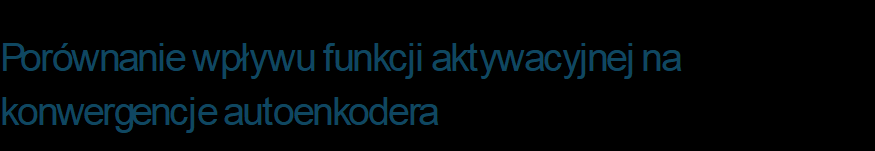
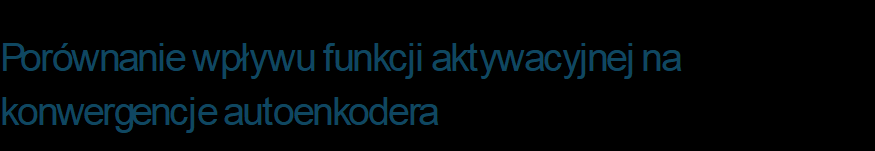
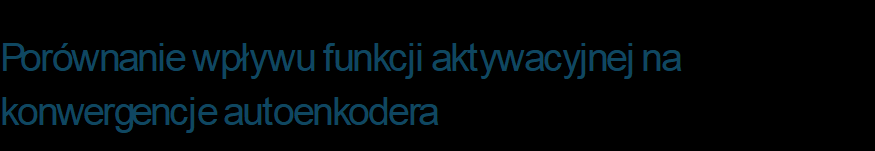

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

epochs = 15
batch_size = 2048

activation_functions = ['relu', 'elu', 'tanh']
for j in range(3):
    histories = {}
    feature_count = X_scaled.shape[1]

    for func in activation_functions:
        print(f"Model training using {func.upper()} function.")

        model = Sequential([
            Input(shape=(feature_count,)),

            #Encoder
            Dense(6, activation=func),

            #Bottleneck
            Dense(3, activation=func),

            #Decoder
            Dense(6, activation=func),

            #Output
            Dense(feature_count, activation='sigmoid')
        ])

        model.compile(optimizer='adam', loss='mse')


        history = model.fit(
            x=X_scaled,
            y=X_scaled,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            shuffle=True,
            verbose=2
        )

        histories[func] = history.history

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Iteration {j}", fontsize=16)

    for i, act in enumerate(activation_functions):
        ax = axes[i]
        ax.plot(histories[act]['loss'], label='Training (loss)', color='blue', linewidth=2)
        ax.plot(histories[act]['val_loss'], label='Validation (val_loss)', color='orange', linewidth=2)
        ax.set_title(f'Activation function: {act.upper()}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE')
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()


# Badanie wymiarowości danych

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

epochs = 15
batch_size = 2048
neurons = [3, 1]


for j in range(3):
    histories = {}
    feature_count = X_scaled.shape[1]

    for neuron in neurons:

        model = Sequential([
            Input(shape=(feature_count,)),

            #Encoder
            Dense(6, activation='relu'),

            #Bottleneck
            Dense(neuron, activation='relu'),

            #Decoder
            Dense(6, activation='relu'),

            #Output
            Dense(feature_count, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='mse')

        history = model.fit(
            x=X_scaled,
            y=X_scaled,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            shuffle=True,
            verbose=2
        )

        histories[neuron] = history.history


    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f"Iteration: {j}", fontsize=16)

    for i, neuron in enumerate(neurons):
        ax = axes[i]


        ax.plot(histories[neuron]['loss'], label='MSE (Training)', color='blue', linewidth=2)
        ax.plot(histories[neuron]['val_loss'], label='MSE (Validation)', color='orange', linewidth=2)

        ax.set_title(f'Bottleneck: {neuron} neurons')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# Fabryka modeli

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

unique_ids = sorted(df['CAN_ID'].unique())

results = []
start_global = time.time()

for i, can_id in enumerate(unique_ids):
    print(f"[{i+1}/{len(unique_ids)}] Processing CAN ID: {can_id} ...", end=" ")

    df_temp = df[df['CAN_ID'] == can_id].copy()
    df_temp = df_temp[df_temp['delta_t'] > 0.0]
    X_raw = df_temp.drop(columns=['Timestamp', 'CAN_ID']).fillna(0)

    if len(X_raw) < 1000:
        print(f"Skipped (too few frames: {len(X_raw)})")
        continue

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_raw)
    feature_count = X_scaled.shape[1]

    model_ae = Sequential([
        Input(shape=(feature_count,)),
        Dense(6, activation='relu'),
        Dense(3, activation='relu'),
        Dense(6, activation='relu'),
        Dense(feature_count, activation='sigmoid')
    ])
    model_ae.compile(optimizer='adam', loss='mse')

    history = model_ae.fit(X_scaled, X_scaled, epochs=15, batch_size=2048, validation_split=0.1, verbose=0)
    final_mse = history.history['val_loss'][-1]

    iso_forest = IsolationForest(n_estimators=100, contamination=0.001, random_state=SEED, n_jobs=-1)
    iso_forest.fit(X_scaled)

    anomaly_scores = iso_forest.score_samples(X_scaled) * -1
    mean_iforest_score = np.mean(anomaly_scores)

    results.append({
        'CAN_ID': str(can_id),
        'Frame_Count': len(X_scaled),
        'AE_Threshold_MSE': final_mse,
        'IForest_Mean_Score': mean_iforest_score
    })
    print(f"Finished! (MSE: {final_mse:.4f})")

total_time = time.time() - start_global
print(f"\nFinished profiling {len(unique_ids)} modules in {total_time:.2f} seconds!")

df_results = pd.DataFrame(results)

plt.figure(figsize=(14, 6))
bars = plt.bar(df_results['CAN_ID'], df_results['AE_Threshold_MSE'], color='royalblue', edgecolor='black')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.4f}', ha='center', va='bottom', fontsize=8, rotation=45)

plt.title(': Learned error threshold (MSE) for every CAN module', fontsize=14)
plt.title('Database: Learned error threshold (MSE) for every CAN module', fontsize=14)
plt.xlabel('CAN_ID', fontsize=12)
plt.ylabel('MSE on clean data (Threshold)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nFragment of a generated database (Baseline):")
display(df_results.head())
